# Medicare Patient Segmentation — End-to-End Pipeline

**Data:** CMS DE-SynPUF Sample 1, 2008–2010  
**Question:** Which patient segments drive disproportionate cost and utilization among beneficiaries with chronic conditions?  

Run this notebook after `python scripts/download_data.py`.  
Outputs are written to `data/processed/` and used by `briefing/exec_briefing.qmd` and `dashboard/app.py`.

In [1]:
import sys
sys.path.insert(0, '../src')

import logging
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import adjusted_rand_score

import patientseg.io as psio
from patientseg.cohort import build_cohort, cohort_attrition_table
from patientseg.features import assemble_feature_matrix
from patientseg.cluster import (
    preprocess, fit_kmeans_sweep, fit_gmm_sweep,
    pick_k_kmeans, pick_k_gmm, refit_kmeans, refit_gmm,
    compare_algorithms,
)
from patientseg.stability import cluster_stability
from patientseg.profile import profile_segments, name_segments
from patientseg.prioritize import build_prioritization_table

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

print('Environment OK')

Environment OK


## 1. Convert raw CSVs to Parquet

In [2]:
for file_type in ['bsf', 'ip', 'op', 'carrier', 'pde']:
    for year in [2008, 2009, 2010]:
        try:
            path = psio.convert_to_parquet(file_type, year)
            print(f'  {file_type} {year} → {path}')
        except FileNotFoundError as e:
            print(f'  SKIPPED {file_type} {year}: {e}')

INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2008.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2009.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2010.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/ip_2008.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/ip_2009.parquet


...

INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/op_2010.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/carrier_2008.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/carrier_2009.parquet


INFO: Parquet already exists: /Users/shirishghimire/projects/patientsegmentation/data/processed/carrier_2010.parquet


  bsf 2008 → /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2008.parquet
  bsf 2009 → /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2009.parquet
  bsf 2010 → /Users/shirishghimire/projects/patientsegmentation/data/processed/bsf_2010.parquet
  ip 2008 → /Users/shirishghimire/projects/patientsegmentation/data/processed/ip_2008.parquet
  ip 2009 → /Users/shirishghimire/projects/patientsegmentation/data/processed/ip_2009.parquet
  ip 2010 → /Users/shirishghimire/projects/patientsegmentation/data/processed/ip_2010.parquet
  op 2008 → /Users/shirishghimire/projects/patientsegmentation/data/processed/op_2008.parquet
  op 2009 → /Users/shirishghimire/projects/patientsegmentation/data/processed/op_2009.parquet
  op 2010 → /Users/shirishghimire/projects/patientsegmentation/data/processed/op_2010.parquet
  carrier 2008 → /Users/shirishghimire/projects/patientsegmentation/data/processed/carrier_2008.parquet
  carrier 2009 → /Users/shirishghimire/proje

## 2. Load data

In [3]:
bsf_2008 = psio.load_parquet('bsf', 2008)
bsf_2009 = psio.load_parquet('bsf', 2009)
bsf_2010 = psio.load_parquet('bsf', 2010)

ip_2009   = psio.load_parquet('ip', 2009)
op_2009   = psio.load_parquet('op', 2009)
car_2009  = psio.load_parquet('carrier', 2009)

ip_2010   = psio.load_parquet('ip', 2010)
op_2010   = psio.load_parquet('op', 2010)

try:
    pde_2009 = psio.load_parquet('pde', 2009)
    print(f'PDE 2009: {len(pde_2009):,} rows')
except FileNotFoundError:
    pde_2009 = None
    print('PDE not available — polypharmacy feature will be 0')

print(f'BSF 2009: {len(bsf_2009):,} rows | BSF 2010: {len(bsf_2010):,} rows')

PDE not available — polypharmacy feature will be 0
BSF 2009: 114,538 rows | BSF 2010: 112,754 rows


## 3. Build cohort

In [4]:
cohort = build_cohort(bsf_2009, bsf_2010)
print(f'\nFinal cohort: {len(cohort):,} beneficiaries')

# Attrition table
attrition = cohort_attrition_table(bsf_2009, bsf_2010)
attrition.to_parquet(PROCESSED / 'cohort_attrition.parquet', index=False)
display(attrition)

INFO: Cohort build: starting with 114538 beneficiaries in BSF 2009


INFO:   After A/B 12-month 2009: 104046 (-10492)


INFO:   After no HMO 2009: 72685


INFO:   After inner join to BSF 2010: 71562


INFO:   After A/B 12-month 2010: 66275


INFO:   After no HMO 2010: 60013


INFO:   After alive at 2010-01-01: 60013


INFO:   After ≥1 chronic condition: 45305 (final cohort)



Final cohort: 45,305 beneficiaries


,Step,N,Removed
0,BSF 2009 — all beneficiaries,114538,0
1,Continuous A+B 2009 (12 months),104046,10492
2,No HMO enrollment 2009,72685,31361
3,Also enrolled 2010 (inner join),71562,1123
4,Continuous A+B 2010 (12 months),66275,5287
5,No HMO enrollment 2010,60013,6262
6,Alive at 2010-01-01,60013,0
7,≥1 CCW chronic condition in 2009,45305,14708


## 4. Feature engineering

In [5]:
features = assemble_feature_matrix(
    cohort=cohort,
    ip_2009=ip_2009,
    op_2009=op_2009,
    carrier_2009=car_2009,
    bsf_2010=bsf_2010,
    ip_2010=ip_2010,
    op_2010=op_2010,
    pde_2009=pde_2009,
)

print(f'Feature matrix: {features.shape}')
print('\nSanity checks:')
print(f'  Mean 2009 cost: ${features["total_cost_2009"].mean():,.0f}')
print(f'  Mean # chronic conditions: {features["n_chronic_conditions"].mean():.1f}')
print(f'  Pct with diabetes: {(features["SP_DIABETES"].mean()*100):.1f}%')
print(f'  Pct with CHF: {(features["SP_CHF"].mean()*100):.1f}%')

features.to_parquet(PROCESSED / 'cohort_features.parquet', index=False)

INFO: Building clinical complexity features...


INFO: Building utilization features...


INFO: Building demographic features...


INFO: Building 2010 outcome features (held out)...


INFO: Feature matrix: 45305 rows × 30 columns


Feature matrix: (45305, 30)

Sanity checks:
  Mean 2009 cost: $6,308
  Mean # chronic conditions: 3.8
  Pct with diabetes: 62.0%
  Pct with CHF: 50.9%


## 5. Preprocessing

In [6]:
X, preprocessor = preprocess(features)

# Outcome variable for evaluation (never used in clustering)
cost_2010 = features['total_cost_2010'].fillna(0).values

print(f'Preprocessed matrix: {X.shape}')

INFO: Preprocessed feature matrix: (45305, 29)


Preprocessed matrix: (45305, 29)


## 6. Model selection — K-Means sweep

INFO: K-means k=2 | sil=0.174 | DB=2.218 | F=901.2


INFO: K-means k=3 | sil=0.128 | DB=2.576 | F=463.1


INFO: K-means k=4 | sil=0.072 | DB=2.887 | F=327.2


INFO: K-means k=5 | sil=0.076 | DB=2.713 | F=238.8


INFO: K-means k=6 | sil=0.074 | DB=2.615 | F=259.0


INFO: K-means k=7 | sil=0.068 | DB=2.589 | F=211.0


INFO: K-means k=8 | sil=0.074 | DB=2.490 | F=189.6


INFO: K-means k=9 | sil=0.068 | DB=2.582 | F=168.6


INFO: K-means k=10 | sil=0.066 | DB=2.513 | F=149.9


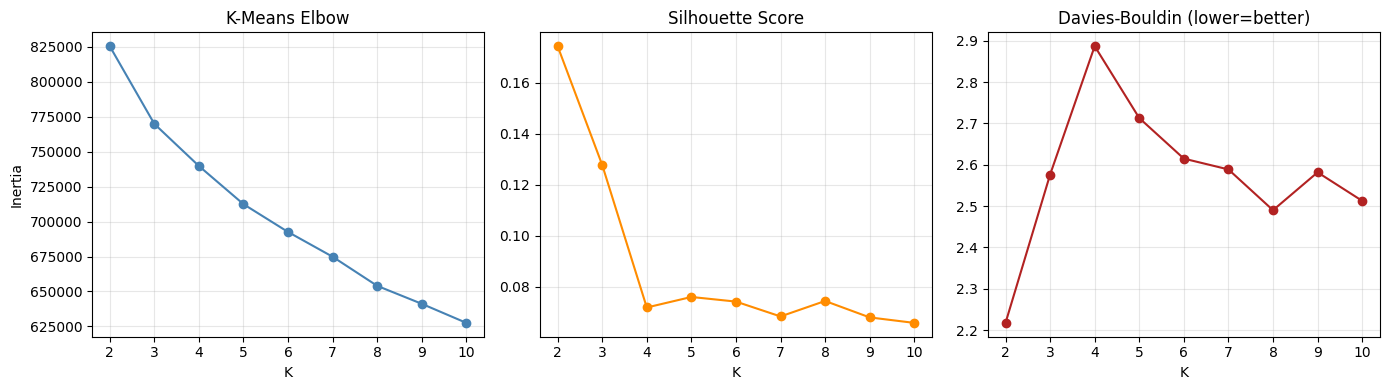


Chosen K for K-Means: 5 (silhouette=0.076)


In [7]:
km_sweep = fit_kmeans_sweep(X, cost_2010, k_range=range(2, 11))

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = sorted(km_sweep)
axes[0].plot(ks, [km_sweep[k].inertia for k in ks], 'o-', color='steelblue')
axes[0].set(title='K-Means Elbow', xlabel='K', ylabel='Inertia')
axes[1].plot(ks, [km_sweep[k].silhouette for k in ks], 'o-', color='darkorange')
axes[1].set(title='Silhouette Score', xlabel='K')
axes[2].plot(ks, [km_sweep[k].davies_bouldin for k in ks], 'o-', color='firebrick')
axes[2].set(title='Davies-Bouldin (lower=better)', xlabel='K')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../briefing/figures/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k_km = pick_k_kmeans(km_sweep)
print(f'\nChosen K for K-Means: {k_km} (silhouette={km_sweep[k_km].silhouette:.3f})')

## 7. Model selection — GMM sweep

INFO: GMM k=2 | sil=0.145 | DB=2.649 | BIC=-1816549.4 | F=382.4


INFO: GMM k=3 | sil=0.094 | DB=3.020 | BIC=-2497200.9 | F=267.3


INFO: GMM k=4 | sil=0.081 | DB=3.281 | BIC=-2774557.4 | F=196.5


INFO: GMM k=5 | sil=0.046 | DB=2.912 | BIC=-3233974.1 | F=143.8


INFO: GMM k=6 | sil=0.071 | DB=2.891 | BIC=-3247955.3 | F=122.1


INFO: GMM k=7 | sil=0.053 | DB=3.052 | BIC=-3617792.2 | F=151.1


INFO: GMM k=8 | sil=0.035 | DB=2.904 | BIC=-3755778.7 | F=118.5


INFO: GMM k=9 | sil=0.029 | DB=3.025 | BIC=-3844495.6 | F=100.7


INFO: GMM k=10 | sil=0.038 | DB=3.195 | BIC=-4041298.5 | F=110.2


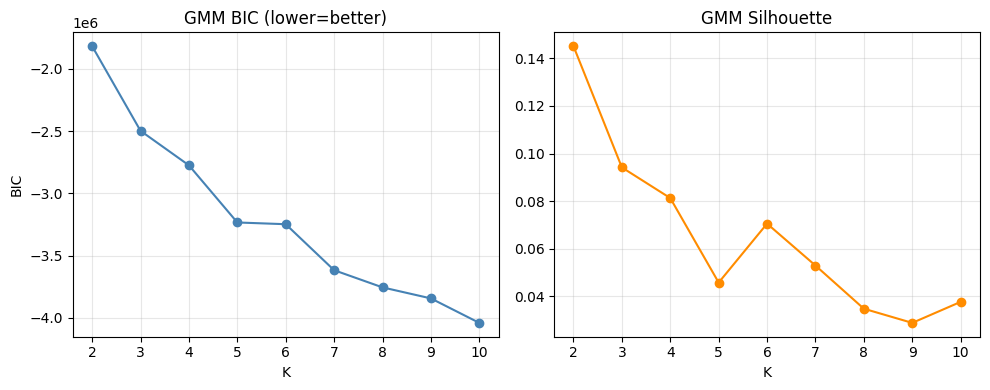


Chosen K for GMM: 10 (BIC=-4041298.5)


In [8]:
gmm_sweep = fit_gmm_sweep(X, cost_2010, k_range=range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ks = sorted(gmm_sweep)
axes[0].plot(ks, [gmm_sweep[k].bic for k in ks], 'o-', color='steelblue')
axes[0].set(title='GMM BIC (lower=better)', xlabel='K', ylabel='BIC')
axes[1].plot(ks, [gmm_sweep[k].silhouette for k in ks], 'o-', color='darkorange')
axes[1].set(title='GMM Silhouette', xlabel='K')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../briefing/figures/gmm_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k_gmm = pick_k_gmm(gmm_sweep)
print(f'\nChosen K for GMM: {k_gmm} (BIC={gmm_sweep[k_gmm].bic:.1f})')

## 8. Final model fits

In [9]:
km_model, km_result = refit_kmeans(X, k_km, cost_2010)
gmm_model, gmm_result = refit_gmm(X, k_gmm, cost_2010)

ari = adjusted_rand_score(km_result.labels, gmm_result.labels)
print(f'ARI between K-Means ({k_km} clusters) and GMM ({k_gmm} clusters): {ari:.3f}')

ARI between K-Means (5 clusters) and GMM (10 clusters): 0.254


## 9. Stability validation (80% × 20 resamples)

In [10]:
print('Running K-Means stability (20 iterations)...')
km_stability = cluster_stability(X, km_result.labels, 'kmeans', k_km,
                                  n_iter=20, subsample_frac=0.80)
print('Running GMM stability (20 iterations)...')
gmm_stability = cluster_stability(X, gmm_result.labels, 'gmm', k_gmm,
                                   n_iter=20, subsample_frac=0.80)

print('\nK-Means stability:')
display(km_stability)
print('\nGMM stability:')
display(gmm_stability)

all_stability = pd.concat([
    km_stability.assign(algorithm='kmeans'),
    gmm_stability.assign(algorithm='gmm'),
])
all_stability.to_parquet(PROCESSED / 'stability_results.parquet', index=False)

Running K-Means stability (20 iterations)...


INFO: Stability: completed 5/20 iterations


INFO: Stability: completed 10/20 iterations


INFO: Stability: completed 15/20 iterations


INFO: Stability: completed 20/20 iterations


...

INFO: Stability: completed 20/20 iterations



K-Means stability:


,cluster,mean_jaccard,std_jaccard,n_stable_iters,n_iters,stability_tier
0,0,0.809394,0.249594,15,20,Stable (0.60–0.84)
1,1,0.763838,0.244461,14,20,Stable (0.60–0.84)
2,2,0.793501,0.170575,19,20,Stable (0.60–0.84)
3,3,0.768287,0.266627,14,20,Stable (0.60–0.84)
4,4,0.578226,0.415069,10,20,Unstable (<0.60)



GMM stability:


,cluster,mean_jaccard,std_jaccard,n_stable_iters,n_iters,stability_tier
0,0,0.142869,0.018125,0,20,Unstable (<0.60)
1,1,0.467620,0.094277,9,20,Unstable (<0.60)
2,2,0.167684,0.014375,0,20,Unstable (<0.60)
3,3,0.889488,0.258076,18,20,Highly stable (≥0.85)
4,4,0.463807,0.141999,8,20,Unstable (<0.60)
5,5,0.398372,0.138835,5,20,Unstable (<0.60)
6,6,0.378201,0.227493,9,20,Unstable (<0.60)
7,7,0.108023,0.071115,0,20,Unstable (<0.60)
8,8,0.347819,0.080929,1,20,Unstable (<0.60)
9,9,0.279191,0.083153,1,20,Unstable (<0.60)


## 10. Algorithm comparison and choice

In [11]:
comparison = compare_algorithms(km_result, gmm_result, km_stability, gmm_stability)

print(f'\n=== ALGORITHM CHOICE: {comparison.chosen.upper()} ===')
print(f'Justification: {comparison.justification}')
print(f'ARI: {comparison.ari:.3f}')
print()
display(comparison.to_dataframe())

comparison.to_dataframe().to_parquet(PROCESSED / 'model_comparison.parquet', index=False)

INFO: Algorithm choice: kmeans — K-means mean Jaccard=0.74 vs GMM=0.36. Chose K-means on stability grounds. (ARI=0.25)



=== ALGORITHM CHOICE: KMEANS ===
Justification: K-means mean Jaccard=0.74 vs GMM=0.36. Chose K-means on stability grounds.
ARI: 0.254



,Algorithm,K,Silhouette,Davies-Bouldin,BIC,Inertia,Cost F-stat (2010)
0,KMEANS,5,0.076,2.713,NaN,712474.4,238.8
1,GMM,10,0.028,3.209,-4097854.4,NaN,91.4


## 11. Segment profiling

In [12]:
# Profile both algorithms; dashboard shows both
km_profile = profile_segments(features, km_result.labels, km_stability, 'kmeans')
km_profile = name_segments(km_profile)
km_prio    = build_prioritization_table(km_profile)

gmm_profile = profile_segments(features, gmm_result.labels, gmm_stability, 'gmm')
gmm_profile = name_segments(gmm_profile)
gmm_prio    = build_prioritization_table(gmm_profile)

segments = pd.concat([km_prio, gmm_prio], ignore_index=True)
segments.to_parquet(PROCESSED / 'segments.parquet', index=False)

print('\nK-Means segments:')
display(km_prio[['segment_name', 'n', 'pct_of_cohort', 'mean_cost_2010',
                  'outreach_intensity', 'mean_jaccard', 'stability_tier']])

INFO: Segment profile: 5 segments


INFO: Segment profile: 10 segments



K-Means segments:


,segment_name,n,pct_of_cohort,mean_cost_2010,outreach_intensity,mean_jaccard,stability_tier
0,Advanced-Disease / End-of-Life,3217,7.1,4864.0,Intensive,0.578226,Unstable (<0.60)
1,"High-Complexity, Low-Utilization",10242,22.6,4522.0,Intensive,0.793501,Stable (0.60–0.84)
2,"High-Complexity, High-Utilization",7775,17.2,4434.0,Intensive,0.763838,Stable (0.60–0.84)
3,"Well-Managed, Stable Chronic",13293,29.3,2873.0,Moderate,0.768287,Stable (0.60–0.84)
4,"Low-Acuity, Preventive-Focus",10778,23.8,2415.0,Light-Touch,0.809394,Stable (0.60–0.84)


## 12. Key visualizations

In [13]:
# Chosen algorithm profile
chosen_profile = km_prio if comparison.chosen == 'kmeans' else gmm_prio

# Cost × size bubble chart
fig = px.scatter(
    chosen_profile,
    x='segment_name', y='mean_cost_2010',
    size='n', color='outreach_intensity',
    color_discrete_map={'Intensive': '#c0392b', 'Moderate': '#e67e22',
                         'Light-Touch': '#27ae60', 'Specialized': '#8e44ad'},
    labels={'segment_name': 'Segment', 'mean_cost_2010': 'Mean 2010 Cost ($)',
             'outreach_intensity': 'Outreach Intensity'},
    title='Patient Segments: Size and Mean 2010 Cost',
    height=450,
)
fig.update_layout(xaxis_tickangle=-20, plot_bgcolor='white',
                  margin={'t': 60, 'b': 100})
fig.update_yaxes(tickprefix='$', tickformat=',.0f', gridcolor='#eee')
fig.show()
fig.write_image('../briefing/figures/segment_cost_size.png', width=900, height=450, scale=2)

INFO: Chromium init'ed with kwargs {}


INFO: Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmpinjwarre.


INFO: Opening browser.


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmprk_xz3pr.


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


In [14]:
# CCW condition prevalence heatmap
ccw_cols = [c for c in chosen_profile.columns if c.startswith('pct_SP_')]
ccw_labels = {
    'pct_SP_ALZHDMTA': "Alzheimer's", 'pct_SP_CHF': 'CHF',
    'pct_SP_CHRNKIDN': 'CKD', 'pct_SP_CNCR': 'Cancer',
    'pct_SP_COPD': 'COPD', 'pct_SP_DEPRESSN': 'Depression',
    'pct_SP_DIABETES': 'Diabetes', 'pct_SP_ISCHMCHT': 'IHD',
    'pct_SP_OSTEOPRS': 'Osteoporosis', 'pct_SP_RA_OA': 'RA/OA',
    'pct_SP_STRKETIA': 'Stroke/TIA',
}

if ccw_cols:
    hm_df = chosen_profile.set_index('segment_name')[ccw_cols]
    hm_df.columns = [ccw_labels.get(c, c) for c in hm_df.columns]
    
    fig_hm = px.imshow(
        hm_df, aspect='auto',
        color_continuous_scale='Blues',
        labels={'color': 'Prevalence (%)'},
        title='Condition Prevalence by Segment (%)',
    )
    fig_hm.update_layout(height=300, margin={'t': 60})
    fig_hm.show()
    fig_hm.write_image('../briefing/figures/condition_heatmap.png', width=900, height=350, scale=2)

INFO: Chromium init'ed with kwargs {}


INFO: Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmpeudtn62q.


INFO: Opening browser.


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmpek13tn38.


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


In [15]:
# Stability bar chart
stab_df = km_stability if comparison.chosen == 'kmeans' else gmm_stability
if 'segment_name' in chosen_profile.columns:
    stab_df = stab_df.merge(chosen_profile[['cluster', 'segment_name']], on='cluster', how='left')
    x_col = 'segment_name'
else:
    x_col = 'cluster'

fig_stab = px.bar(
    stab_df, x=x_col, y='mean_jaccard',
    error_y='std_jaccard',
    color='stability_tier',
    color_discrete_map={
        'Highly stable (≥0.85)': '#27ae60',
        'Stable (0.60–0.84)': '#f39c12',
        'Unstable (<0.60)': '#e74c3c',
    },
    labels={x_col: 'Segment', 'mean_jaccard': 'Mean Jaccard (20 iterations)'},
    title='Cluster Stability: Mean Jaccard Similarity (80% Resample × 20 Iterations)',
    height=350,
)
fig_stab.add_hline(y=0.85, line_dash='dash', line_color='#27ae60',
                    annotation_text='Highly stable (0.85)')
fig_stab.add_hline(y=0.60, line_dash='dash', line_color='#f39c12',
                    annotation_text='Stable (0.60)')
fig_stab.update_layout(plot_bgcolor='white', margin={'t': 60, 'b': 80},
                        xaxis_tickangle=-20)
fig_stab.update_yaxes(range=[0, 1.05], gridcolor='#eee')
fig_stab.show()
fig_stab.write_image('../briefing/figures/stability.png', width=900, height=380, scale=2)

INFO: Chromium init'ed with kwargs {}


INFO: Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmp0_v_mno0.


INFO: Opening browser.


INFO: Temp directory created: /var/folders/1x/49wlh81n0yz5p1tsp_1qrc8h0000gn/T/tmpaidrmzks.


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


In [16]:
print('Pipeline complete.')
print(f'Segments written to: {PROCESSED / "segments.parquet"}')
print(f'Figures written to: ../briefing/figures/')
print()
print('Next steps:')
print('  quarto render briefing/exec_briefing.qmd   # build the PDF')
print('  python dashboard/app.py                    # launch the dashboard')

Pipeline complete.
Segments written to: ../data/processed/segments.parquet
Figures written to: ../briefing/figures/

Next steps:
  quarto render briefing/exec_briefing.qmd   # build the PDF
  python dashboard/app.py                    # launch the dashboard
